In [29]:
import polars as pl
import numpy as np
from deq.mle import draft_equity
from deq.plot import line_plot
import matplotlib.pyplot as plt

In [9]:
result = draft_equity('OTJ', 1)

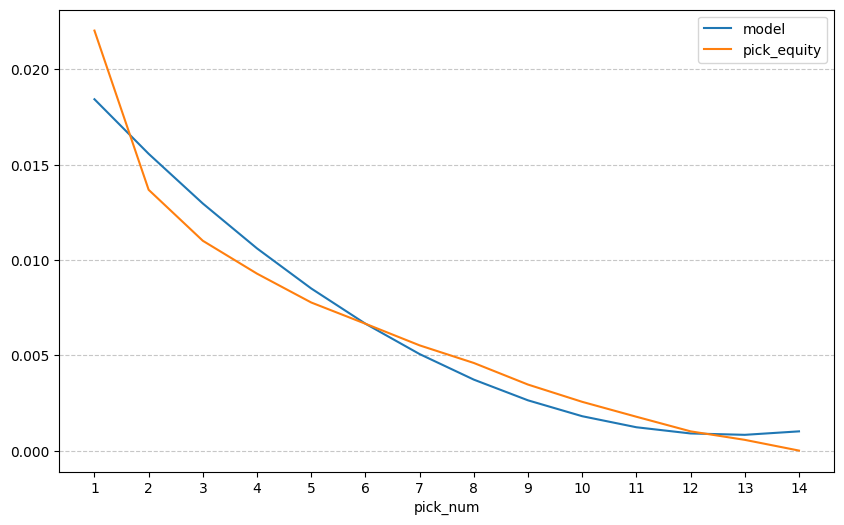

In [37]:
pick_equity_col = -pl.col('remaining_pick_equity').diff().alias('pick_equity_solve')
pick_equity_norm = (pick_equity_col - pick_equity_col.min()).alias('pick_equity')

y = result.pick_equity_df.select('pick_num', pick_equity_norm).filter(pl.col('pick_num') > 0)['pick_equity']
x = np.arange(1,15)
y_fit = np.polyfit(x, y, 2)

df = pl.DataFrame({'pick_num': x, 'model': (y_fit[None, :] @ np.array([x**2, x, np.ones(14)]))[0], 'pick_equity': y})

line_plot(df)

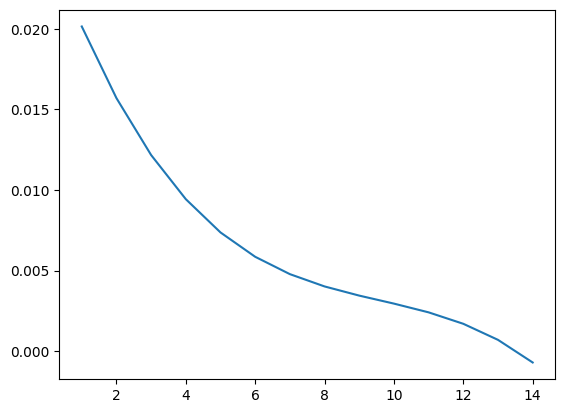

In [32]:
plt.plot(x, )